# Lab 02 - Nhận dạng chữ số viết tay

(Hãy đảm bảo bạn đã đọc qua tutorial LeNet để nắm rõ một số bước cần làm)

Trong Lab 02 này, bạn sẽ tiến hành cài đặt lại mô hình AlexNet [(Khirzhevsky et al. 2012)](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) để train một model nhận dạng chữ số viết tay trên bộ dữ liệu MNIST -- tương tự những gì đã làm ở tutorial LeNet.

**Vui lòng tạo một bản copy của notebook này trên Google Drive của bạn**

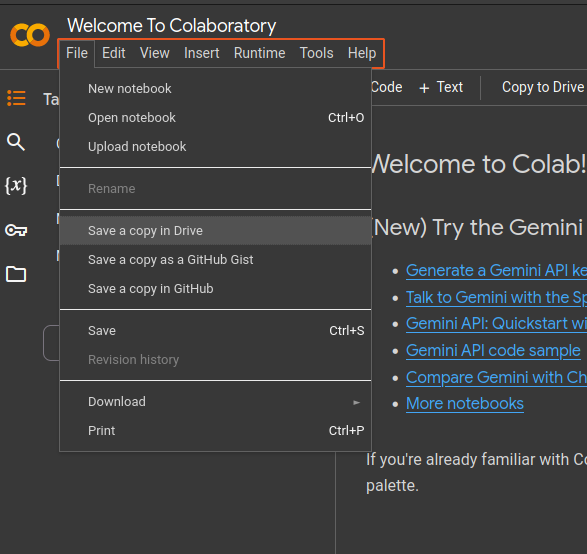

## Hướng dẫn làm bài

Bạn **chỉ điền vào các mục `#TODO` nội dung phù hợp**, sau đó chạy các notebook cells. Tránh modify các đoạn code không có `# TODO` để không bị các bug khác.

## Cài đặt các package cần thiết

Tương tự như LeNet, ta vẫn dùng pytorch và torchvision cho lab này.

In [ ]:
!pip install torch==2.2.0
!pip install torchvision==0.17.0

## Import các package

In [ ]:
import torch, torchvision

## Set seed & một số thông số

In [ ]:
import random
import numpy as np

random_state = 42

torch.manual_seed(random_state)
random.seed(random_state)
np.random.seed(random_state)

In [ ]:
# TODO: một số thông số huấn luyện

# Batch size: 64
batch_size = ...

# Learning rate: 0.001
learning_rate = ...

# Training epochs: 10
num_epochs = ...

In [ ]:
# Kiểm tra batch size, learning rate và số training epochs đã đúng chưa?

print(f"Batch size = {batch_size}, learning_rate = {learning_rate}, num_epochs = {num_epochs}")

Cell trên nên in ra nội dung sau:

```
Batch size = 64, learning_rate = 0.001, num_epochs = 10
```

## Tạo dataloader

In [ ]:
# TODO: tạo training dataset (tương tự notebook LeNet)

training_dataset = ...

In [ ]:
# TODO: tạo testing dataset (tương tự notebook LeNet)

testing_dataset = ...

In [ ]:
# TODO: tạo training dataloader (tương tự notebook LeNet)

training_dataloader = ...

In [ ]:
# TODO: tạo testing dataloader (tương tự notebook LeNet)

testing_dataloader = ...

## Dùng CPU hay GPU?

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

## Model

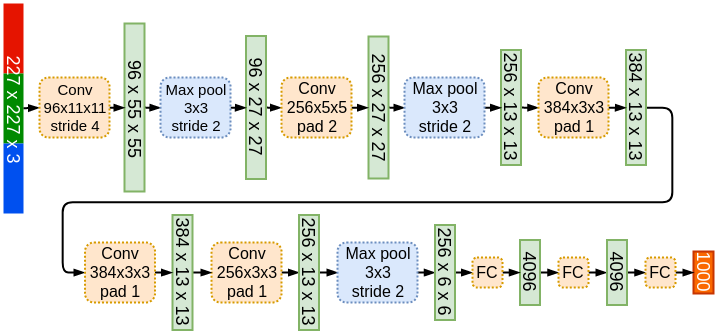

Đây là kiến trúc của AlexNet, train cho bộ ImageNet 1000 class, kích thước mỗi ảnh đầu vào là $227\times 227\times 3$. Ở lab này, ta sẽ hiệu chỉnh một số thông số AlexNet cho MNIST kích thước $32\times 32\times 1$.

Lưu ý: bạn nên **bám sát** miêu tả network.

In [ ]:
class AlexNet(torch.nn.Module):
    def __init__(self, **kwargs):
        self.num_classes = kwargs.get("num_classes", 10)
        self.dropout_rate = kwargs.get("dropout_rate", .5)

        # TODO: self.features gồm 8 layers (các khối màu vàng và xanh dương) như trong hình bên trên.

        self.features = torch.nn.Sequential(
            # torch.nn.Conv2d với in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=1
            torch.nn.Conv2d(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.MaxPool2d với kernel_size=2, stride=2
            torch.nn.MaxPool2d(...),
            # torch.nn.Conv2d với in_channels=32, out_channels=64, kernel_size=3, padding=1
            torch.nn.Conv2d(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.MaxPool2d với kernel_size=2, stride=2
            torch.nn.MaxPool2d(...),
            # torch.nn.Conv2d với in_channels=64, out_channels=96, kernel_size=3, padding=1
            torch.nn.Conv2d(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.Conv2d với in_channels=96, out_channels=64, kernel_size=3, padding=1
            torch.nn.Conv2d(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.Conv2d với in_channels=64, out_channels=32, kernel_size=3, padding=1
            torch.nn.Conv2d(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.MaxPool2d với kernel_size=2, stride=1
            torch.nn.MaxPool2d(...),
        )

        # TODO: nn.AdaptiveAvgPool2d với output_size=(2, 2)

        self.avgpool = torch.nn.AdaptiveAvgPool2d(..)

        # TODO: self.classifier với 3 layer fully-connected và 2 layer dropout

        self.classifier = torch.nn.Sequential(
            torch.nn.Dropout(p=self.dropout_rate),
            # torch.nn.Linear với in_features=32*2*2, out_features=2048
            torch.nn.Linear(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            torch.nn.Dropout(p=self.dropout_rate),
            # torch.nn.Linear với in_features=2048, out_features=2048
            torch.nn.Linear(...),
            # torch.nn.ReLU với inplace=True
            torch.nn.ReLU(...),
            # torch.nn.Linear với in_features=2048, out_features=self.num_classes
            torch.nn.Linear(...),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

In [ ]:
# TODO: Khai báo model với dropout_rate=0.5, num_classes=10

model = AlexNet(...).to(device)

In [ ]:
# TODO: Hàm loss
# dùng torch.nn.CrossEntropyLoss()

loss_fn = ...

In [ ]:
# TODO: Optimizer
# dùng torch.optim.Adam() với model.parameters(), lr=learning_rate (xem notebook LeNet)

optimizer = ...

In [ ]:
# Số step train -- dùng lúc log cho vui thôi vì mình train theo epoch
total_steps = len(train_dataloader)

## Training

In [ ]:
# TODO: train model

for epoch in range(...):
    for i, (images, labels) in enumerate(train_dataloader):
        images = ...
        labels = ...

        # Forward
        outputs = ...
        loss = ...

        # Backprop
        ...
        ...
        ...

        if (i % 100 == 0):
            print(f"Epoch: {epoch + 1}/{num_epochs} | Step: {i + 1}/{total_steps} | Loss: {loss.item():.4f}")

**Chú ý**: bạn đang train 10 epochs, khác với LeNet chỉ train trong 1 epoch. Vì vậy cân nhắc bật GPU lên train cho lẹ nhé!

Cách bật GPU: xem lại notebook LeNet

## Testing

In [ ]:
# TODO: test kết quả model

with torch.no_grad():
    correct_predictions = ...
    total_samples = ...

    for images, labels in test_dataloader:
        images = ...
        labels = ...

        outputs = ...

        _, predictions = ...
        total_samples += ...
        correct_predictions += ...

    test_accuracy = ...

    print(f"Testing accuracy: {test_accuracy:.4f}")

## Visualizing confusion matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
test_predictions = []
test_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)

        _, predictions = torch.max(outputs.data, 1)

        test_predictions.extend(predictions.tolist())

        test_labels.extend(labels.tolist())

In [ ]:
# TODO: in classification_report

print(classification_report(..., ...))

In [ ]:
# TODO: vẽ confusion matrix

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(confusion_matrix(..., ...), annot=True, ax=ax)
plt.plot()

# Hướng dẫn nộp bài

Sau khi hoàn thành các phần code & train model, **nhớ save notebook**.

Download notebook về:

```
File > Download > Download .ipynb
```

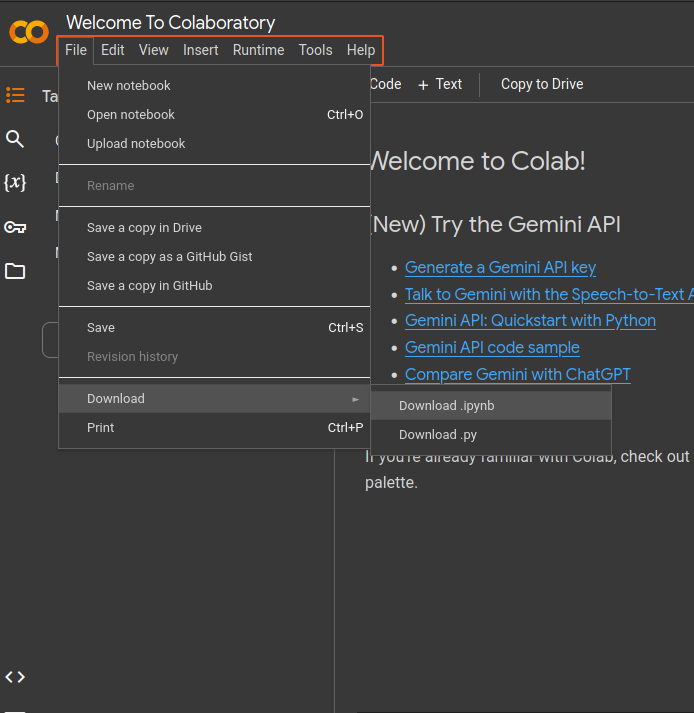

Đổi tên file notebook thành `MSSV-alexnet.ipynb` (VD: `21121234-alexnet.ipynb`), sau đó nộp lên Moodle.

Have fun & happy coding!